# 02. Matplotlib Fundamentals
## 📚 Learning Objectives

By completing this notebook, you will:
- Create basic Matplotlib figures and axes
- Customize plots and add labels
- Save figures and reuse styles

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 1, lesson 01 "Python Libraries for AI", which first used Matplotlib — here the figure/axes object model behind those plots is made explicit so charts can be composed and saved.

**Used later in:** Course 05 — Unit 3, lessons 03 and 06; Seaborn and every customisation trick sit on top of this object model.

---


## 🎯 The case: one software licence, shared by a whole lab

In 2002 **John D. Hunter** was a postdoc at the University of Chicago hospital, analysing
**electrocorticography (ECoG)** recordings from children with epilepsy — electrodes placed
directly on the cortex, hunting for the origin of a seizure. The lab's analysis software
was proprietary and the lab held **one licence**. Graduate students, medical students,
postdocs and investigators took turns passing around the hardware dongle.

Hunter's response was to write his own plotting library, deliberately borrowing MATLAB's
interface so his colleagues could switch without relearning anything. He released
**matplotlib** in 2003 and published the reference paper in *Computing in Science &
Engineering* in 2007.

That library is now the default plotting layer of Python science. The **Event Horizon
Telescope** collaboration used matplotlib to produce visualisations while creating the
first image of a black hole, and in 2024 **NASA awarded a grant** to support its continued
development as critical open-source scientific software. It started because a postdoc could
not get to the dongle.

**What goes wrong without this lesson.** Every other plotting library you will use —
seaborn, pandas `.plot()`, much of plotly's static export — is a wrapper that eventually
returns a matplotlib **Figure** and **Axes**. When a seaborn one-liner produces a chart that
is 90% right, the last 10% is always fixed by reaching through to the object model you are
about to learn. Skip it, and you will be stuck with whatever defaults the wrapper chose.


---

---

## The Story: Learning to Draw

Imagine you're learning art. **Before** creating masterpieces, you learn basic drawing - 
lines, shapes, colors. **After** mastering basics, you can create beautiful artwork!

Same with visualization: **Before** creating advanced plots, we learn matplotlib basics - 
line plots, bar charts, histograms. **After** mastering basics, we can create beautiful 
data visualizations!

---

## Why Matplotlib Matters

Matplotlib is essential because:
- **Foundation**: All Python visualization libraries build on matplotlib
- **Flexibility**: Full control over every plot element
- **Standard**: Most widely used Python plotting library
- **Static Plots**: Perfect for reports, papers, presentations

## Learning Objectives
1. Create basic plots (line, bar, scatter, histogram)
2. Customize plots (colors, labels, legends, titles)
3. Create subplots (multiple plots in one figure)
4. Save plots to files
5. Understand matplotlib's object-oriented interface


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Data
- matplotlib

**Outputs:** What you'll see when you run the cells

- Basic plots
- Customization examples

---

In [1]:
# WHAT: Import pandas/NumPy/matplotlib (plus patches for annotations).
# WHY: matplotlib is the foundation every other Python plotting library builds on.

# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # For custom shapes and annotations

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Data manipulation (DataFrames)")
print("   - numpy: Numerical operations and array generation")
print("   - matplotlib.pyplot: Main plotting library (creates visualizations)")
print("   - matplotlib.patches: Advanced shapes and annotations")

print("\n" + "=" * 70)
print("Example 2: Matplotlib Fundamentals")
print("=" * 70)
print("\n📚 Prerequisites: Unit 2 completed, clean data ready")
print("🔗 This is Example 02 in Unit 3 - foundation for all visualization")
print("🎯 Goal: Master matplotlib basics for creating static visualizations\n")

✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Data manipulation (DataFrames)
   - numpy: Numerical operations and array generation
   - matplotlib.pyplot: Main plotting library (creates visualizations)
   - matplotlib.patches: Advanced shapes and annotations

Example 2: Matplotlib Fundamentals

📚 Prerequisites: Unit 2 completed, clean data ready
🔗 This is Example 02 in Unit 3 - foundation for all visualization
🎯 Goal: Master matplotlib basics for creating static visualizations



## Part 1: Basic Line Plots

**BEFORE**: You have data but can't visualize it.

**AFTER**: You'll create your first plot - a line plot showing trends!

**Why this matters**: Line plots are the most common visualization - master them first!

## Step 1: Creating Your First Line Plot

**BEFORE**: We have data but haven't plotted it yet.

**AFTER**: We'll create a line plot showing how values change over time!


1. Basic Line Plot
----------------------------------------------------------------------
Loaded 891 real passenger records for the charts below.
✓ Line plot saved


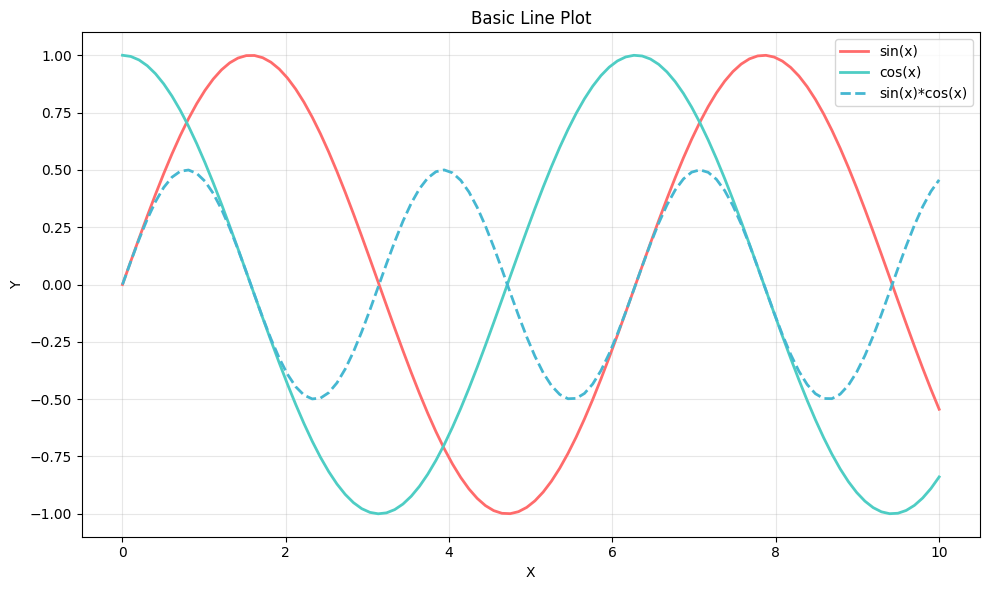

In [2]:
# WHAT: Plot sin/cos curves as a multi-line figure with labels, legend, and grid.
# WHY: The Figure -> Axes -> plot pattern shown here is the skeleton of every matplotlib chart you will ever make.

print("\n1. Basic Line Plot")
print("-" * 70)

# Load the real dataset every other chart in this notebook uses.
DATA_DIR = '../../../Course 04/datasets/raw/'
titanic = pd.read_csv(DATA_DIR + 'titanic.csv')
titanic['Age'] = titanic.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda s: s.fillna(s.median()))
titanic['family_size'] = titanic['SibSp'] + titanic['Parch'] + 1
print(f"Loaded {len(titanic)} real passenger records for the charts below.")

# THIS first plot is the exception: sin and cos are mathematical functions, not a
# dataset. They are here because a smooth known curve makes the Figure -> Axes ->
# plot mechanics obvious. Every chart after this one uses the real data above.
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.cos(x)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y1, label='sin(x)', linewidth=2, color='#FF6B6B')
ax.plot(x, y2, label='cos(x)', linewidth=2, color='#4ECDC4')
ax.plot(x, y3, label='sin(x)*cos(x)', linewidth=2, color='#45B7D1', linestyle='--')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Basic Line Plot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_line_plot.png', dpi=300, bbox_inches='tight')
print("✓ Line plot saved")
plt.show()


## Part 2: Bar Charts

**BEFORE**: You can create line plots but not categorical comparisons.

**AFTER**: You'll create bar charts to compare categories!

**Why this matters**: Bar charts are perfect for comparing discrete categories!

## Step 2: Creating Bar Charts

**BEFORE**: We have categories but can't compare them visually.

**AFTER**: We'll create bar charts to compare category values!


2. Bar Chart
----------------------------------------------------------------------
✓ Bar chart saved


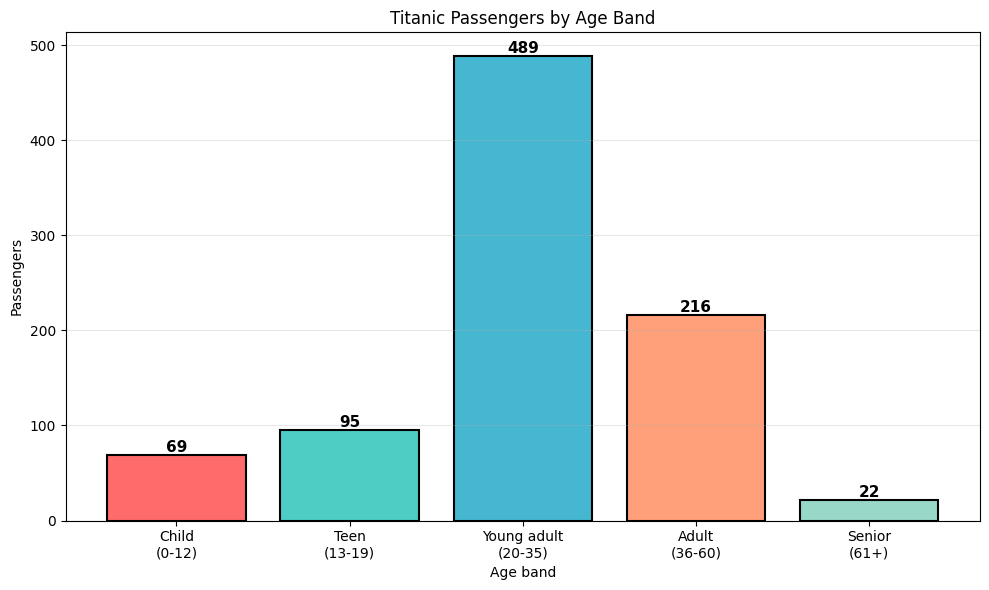

   The ship was overwhelmingly young adults: 489 of 891 passengers.


In [3]:
# WHAT: Draw a bar chart of real passenger counts per age band and write each bar's value above it.
# WHY: Direct value labels save the reader from eyeballing the axis - a small touch that makes charts presentation-ready.

print("\n2. Bar Chart")
print("-" * 70)

# pd.cut turns a continuous column into ordered bands - the standard way to make
# a numeric column bar-chartable.
bands = pd.cut(titanic['Age'],
               bins=[0, 12, 19, 35, 60, 100],
               labels=['Child\n(0-12)', 'Teen\n(13-19)', 'Young adult\n(20-35)',
                       'Adult\n(36-60)', 'Senior\n(61+)'])
band_counts = bands.value_counts().sort_index()
categories = list(band_counts.index)
values = list(band_counts.values)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(categories, values,
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'],
              edgecolor='black', linewidth=1.5)
ax.set_xlabel('Age band')
ax.set_ylabel('Passengers')
ax.set_title('Titanic Passengers by Age Band')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=11, weight='bold')
plt.tight_layout()
plt.savefig('02_bar_chart.png', dpi=300, bbox_inches='tight')
print("✓ Bar chart saved")
plt.show()
print(f"   The ship was overwhelmingly young adults:"
      f" {band_counts.iloc[2]} of {int(band_counts.sum())} passengers.")


## Part 3: Scatter Plots

**BEFORE**: You can plot lines but not relationships between variables.

**AFTER**: You'll create scatter plots to see correlations!

**Why this matters**: Scatter plots reveal relationships and patterns in data!

## Step 3: Creating Scatter Plots

**BEFORE**: We need to see relationships but don't have the right plot type.

**AFTER**: We'll create scatter plots to visualize relationships between variables!


3. Scatter Plot
----------------------------------------------------------------------


✓ Scatter plot saved


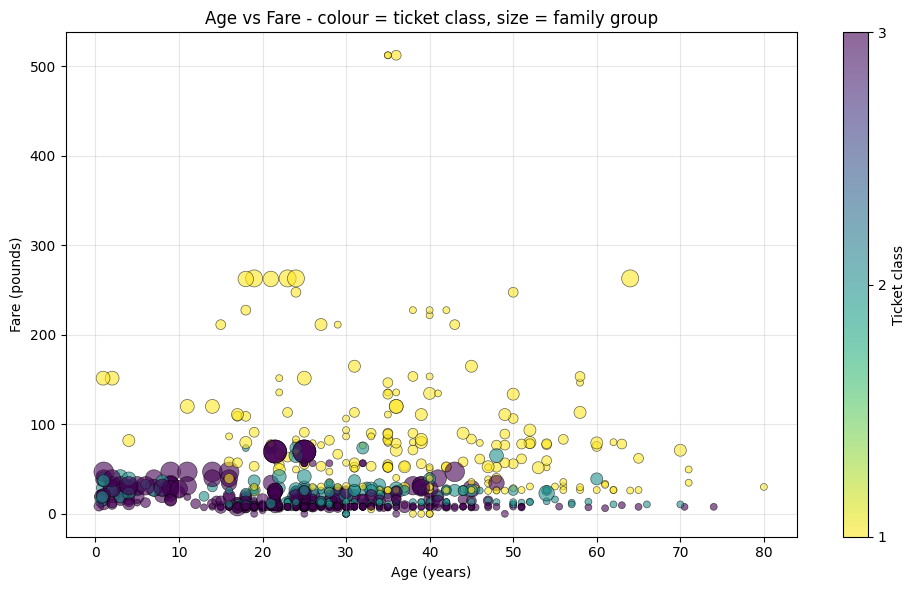

   Read the encodings together, and check each claim against the data:
     - Colour: the tall points really are 1st class (median fare 60 vs 8 in 3rd).
     - Size: bigger dots sit HIGHER, not lower. A lone traveller's median
       fare is 8.14; a group of 5+ paid 31.39, because one Fare
       value covers the whole ticket, not one person.
     - Correlation family_size vs Fare: 0.22 - positive, as the chart shows.
   Four columns, one chart, no legend clutter.


In [4]:
# WHAT: Draw a scatter plot where colour and size encode extra real variables, with a colorbar.
# WHY: Mapping data to colour/size lets one 2D chart carry four dimensions of information.

print("\n3. Scatter Plot")
print("-" * 70)

# Four real variables in one 2D chart:
#   x = age, y = fare paid, colour = ticket class, size = family group size
x_scatter = titanic['Age'].values
y_scatter = titanic['Fare'].values
colors_scatter = titanic['Pclass'].values          # 1, 2 or 3
sizes = titanic['family_size'].values * 25         # scaled so dots stay readable

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(x_scatter, y_scatter, c=colors_scatter, s=sizes,
                     alpha=0.6, cmap='viridis_r', edgecolors='black', linewidth=0.5)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Fare (pounds)')
ax.set_title('Age vs Fare - colour = ticket class, size = family group')
cbar = plt.colorbar(scatter, ax=ax, label='Ticket class', ticks=[1, 2, 3])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03_scatter_plot.png', dpi=300, bbox_inches='tight')
print("✓ Scatter plot saved")
plt.show()
print("   Read the encodings together, and check each claim against the data:")
med_by_class = titanic.groupby('Pclass')['Fare'].median()
print(f"     - Colour: the tall points really are 1st class (median fare"
      f" {med_by_class.loc[1]:.0f} vs {med_by_class.loc[3]:.0f} in 3rd).")
solo = titanic.loc[titanic['family_size'] == 1, 'Fare'].median()
big = titanic.loc[titanic['family_size'] >= 5, 'Fare'].median()
print(f"     - Size: bigger dots sit HIGHER, not lower. A lone traveller's median")
print(f"       fare is {solo:.2f}; a group of 5+ paid {big:.2f}, because one Fare")
print("       value covers the whole ticket, not one person.")
print(f"     - Correlation family_size vs Fare:"
      f" {titanic['family_size'].corr(titanic['Fare']):.2f} - positive, as the chart shows.")
print("   Four columns, one chart, no legend clutter.")


## Part 4: Multiple Subplots

**BEFORE**: You can create one plot at a time.

**AFTER**: You'll create multiple plots in one figure!

**Why this matters**: Subplots let you compare multiple visualizations side-by-side!

## Step 4: Creating Multiple Subplots

**BEFORE**: We can create one plot, but need multiple in one figure.

**AFTER**: We'll create a grid of subplots to compare different visualizations!


4. Multiple Subplots
----------------------------------------------------------------------


✓ Multiple subplots saved


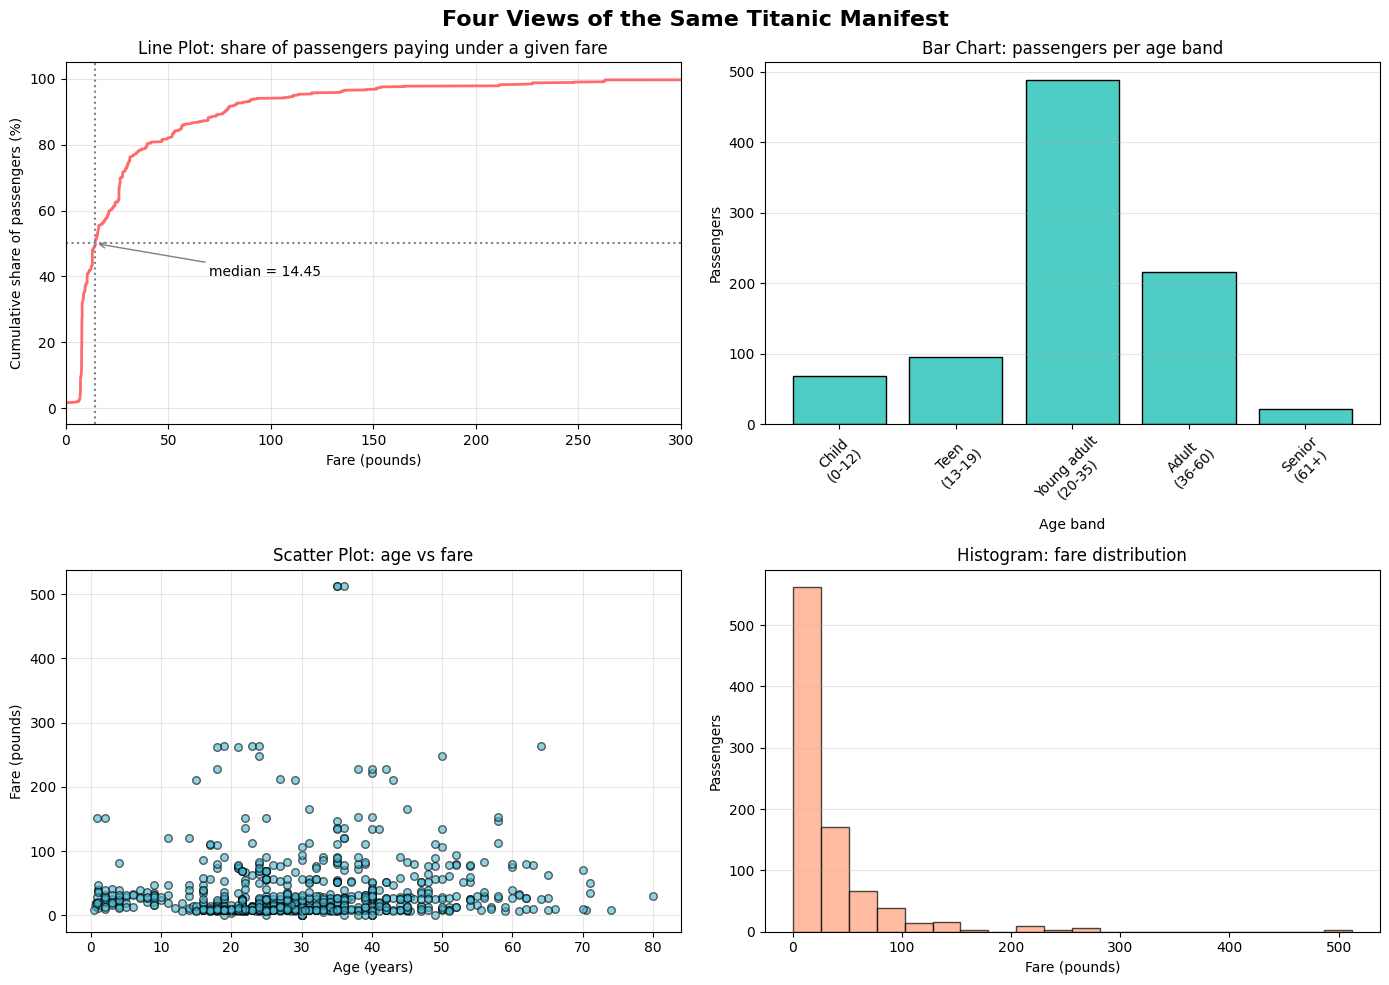

   All four panels describe the same 891 passengers.
   Half of them paid less than 14.45 pounds (51% paid under 15), while the top fare on board was 512.33.


In [5]:
# WHAT: Combine four views of the SAME Titanic manifest - ECDF line, bar, scatter, histogram - in a 2x2 grid.
# WHY: Subplots let related views share one figure, and a shared subject makes the comparison meaningful.

print("\n4. Multiple Subplots")
print("-" * 70)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Four Views of the Same Titanic Manifest', fontsize=16, weight='bold')

# Subplot 1: Line plot - the empirical cumulative distribution of the fares.
# Sorting the fares and plotting rank/N is the cheapest honest line chart you can
# draw from a single column: it answers "what share of passengers paid less than X?"
fare_sorted = np.sort(titanic['Fare'].values)
share = np.arange(1, len(fare_sorted) + 1) / len(fare_sorted)
median_fare = float(np.median(fare_sorted))
axes[0, 0].plot(fare_sorted, share * 100, color='#FF6B6B', linewidth=2)
axes[0, 0].axvline(median_fare, color='grey', linestyle=':', linewidth=1.5)
axes[0, 0].axhline(50, color='grey', linestyle=':', linewidth=1.5)
axes[0, 0].set_title('Line Plot: share of passengers paying under a given fare')
axes[0, 0].set_xlabel('Fare (pounds)')
axes[0, 0].set_ylabel('Cumulative share of passengers (%)')
axes[0, 0].set_xlim(0, 300)
axes[0, 0].annotate(f'median = {median_fare:.2f}', xy=(median_fare, 50),
                    xytext=(70, 40), fontsize=10,
                    arrowprops=dict(arrowstyle='->', color='grey'))
axes[0, 0].grid(True, alpha=0.3)

# Subplot 2: Bar chart - all five age bands, same numbers as the chart in step 2.
axes[0, 1].bar(categories, values, color='#4ECDC4', edgecolor='black')
axes[0, 1].set_title('Bar Chart: passengers per age band')
axes[0, 1].set_xlabel('Age band')
axes[0, 1].set_ylabel('Passengers')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')
# Subplot 3: Scatter plot
axes[1, 0].scatter(x_scatter, y_scatter, alpha=0.6, c='#45B7D1', edgecolors='black', s=30)
axes[1, 0].set_title('Scatter Plot: age vs fare')
axes[1, 0].set_xlabel('Age (years)')
axes[1, 0].set_ylabel('Fare (pounds)')
axes[1, 0].grid(True, alpha=0.3)
# Subplot 4: Histogram
axes[1, 1].hist(y_scatter, bins=20, color='#FFA07A', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Histogram: fare distribution')
axes[1, 1].set_xlabel('Fare (pounds)')
axes[1, 1].set_ylabel('Passengers')
axes[1, 1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('04_multiple_subplots.png', dpi=300, bbox_inches='tight')
print("✓ Multiple subplots saved")
plt.show()
print(f"   All four panels describe the same 891 passengers.")
print(f"   Half of them paid less than {median_fare:.2f} pounds"
      f" ({100 * (titanic['Fare'] < 15).mean():.0f}% paid under 15),"
      f" while the top fare on board was {titanic['Fare'].max():.2f}.")


**Read the figure.** Four panels, one manifest, four different questions. The **line plot**
(top left) climbs almost vertically at the left edge: it crosses 50% at a fare of **14.45
pounds**, so half the ship paid less than that, and the curve is already flat past 100
pounds. The **bar chart** (top right) counts the same people by age band — 489 young adults
against 22 seniors. The **scatter** (bottom left) puts age and fare on one pair of axes and
shows the isolated points at the very top: the highest fare on board, 512.33 pounds. The
**histogram** (bottom right) is the line plot's derivative: one tall bar under 25 pounds,
then a tail nobody would notice in a table.

Note what changes and what does not: the *data* is identical in all four panels, the
*question* is not. That is the whole argument for subplots — put the views that answer
related questions side by side, at the same size, and let the reader compare them.


## Part 5: Advanced Customization

**BEFORE**: You can create basic plots but they look plain.

**AFTER**: You'll customize plots with colors, styles, and annotations!

**Why this matters**: Customization makes plots publication-ready and informative!

## Step 5: Advanced Customization

**BEFORE**: Our plots are functional but not beautiful.

**AFTER**: We'll add colors, styles, annotations, and make plots publication-ready!


5. Advanced Customization
----------------------------------------------------------------------


✓ Customized plot saved


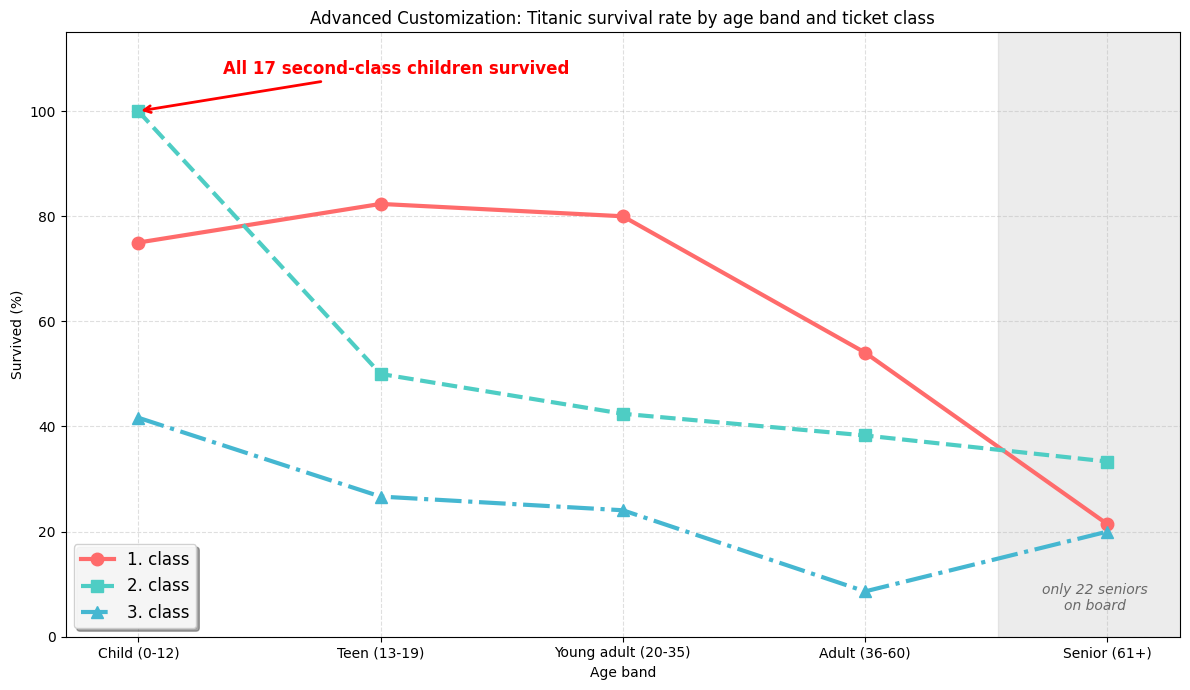

   Survival rate (%) behind the three lines, with the passenger counts:
Pclass                   1      2     3
age_band                               
Child\n(0-12)         75.0  100.0  41.7
Teen\n(13-19)         82.4   50.0  26.7
Young adult\n(20-35)  80.0   42.4  24.1
Adult\n(36-60)        54.1   38.3   8.6
Senior\n(61+)         21.4   33.3  20.0

   Passengers in each cell:
Pclass                  1   2    3
age_band                          
Child\n(0-12)           4  17   48
Teen\n(13-19)          17  18   60
Young adult\n(20-35)   70  99  320
Adult\n(36-60)        111  47   58
Senior\n(61+)          14   3    5


In [6]:
# WHAT: Style three real survival curves (line styles, markers, annotations, shaded caveat) on one axes.
# WHY: Customization controls where the reader looks - here the annotation points at a real finding, and a second annotation warns about a real weakness.

print("\n5. Advanced Customization")
print("-" * 70)

# Survival rate for each age band, split by ticket class - three lines from the
# real manifest. observed=False keeps every band even when a class has few people.
titanic['age_band'] = bands
rate = titanic.pivot_table(index='age_band', columns='Pclass', values='Survived',
                           aggfunc='mean', observed=False) * 100
n_per = titanic.pivot_table(index='age_band', columns='Pclass', values='Survived',
                            aggfunc='size', observed=False)
band_labels = [str(b).replace('\n', ' ') for b in rate.index]
xpos = np.arange(len(band_labels))

fig, ax = plt.subplots(figsize=(12, 7))
styles = {1: ('-', 'o', '#FF6B6B'), 2: ('--', 's', '#4ECDC4'), 3: ('-.', '^', '#45B7D1')}
for cls in [1, 2, 3]:
    ls, mk, col = styles[cls]
    ax.plot(xpos, rate[cls].values, label=f'{cls}. class', linewidth=3,
            color=col, linestyle=ls, marker=mk, markersize=9)

ax.set_xticks(xpos)
ax.set_xticklabels(band_labels)
ax.set_xlabel('Age band')
ax.set_ylabel('Survived (%)')
ax.set_title('Advanced Customization: Titanic survival rate by age band and ticket class')
ax.legend(fontsize=12, loc='lower left', framealpha=0.9, shadow=True)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_xlim(-0.3, len(band_labels) - 0.7)
ax.set_ylim(0, 115)

# Annotation 1: point at the single most striking real value.
kids_2nd = rate.loc[rate.index[0], 2]
ax.annotate(f'All {int(n_per.loc[n_per.index[0], 2])} second-class children survived',
            xy=(0, kids_2nd), xytext=(0.35, 107),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, color='red', weight='bold')

# Annotation 2: an honest warning drawn INTO the chart, not left to a caption.
ax.axvspan(3.55, 4.35, color='grey', alpha=0.15)
ax.text(3.95, 5, f'only {int(n_per.loc[n_per.index[-1]].sum())} seniors\non board',
        ha='center', fontsize=10, color='dimgrey', style='italic')

plt.tight_layout()
plt.savefig('05_customization.png', dpi=300, bbox_inches='tight')
print("✓ Customized plot saved")
plt.show()
print("   Survival rate (%) behind the three lines, with the passenger counts:")
print(rate.round(1).to_string())
print("\n   Passengers in each cell:")
print(n_per.to_string())


**Read the figure.** Three styled lines, one axes. The dash-dot blue **3rd-class** line
stays at the bottom in every single age band, bottoming out at **8.6%** for 3rd-class
adults; the solid red **1st-class** line runs above it everywhere, and above 2nd class from
"Teen" onward. The red arrow marks the one perfect cell in the table: **17 of 17
second-class children survived**. The grey band over the last age group is the
customization that matters most — it says, inside the picture, that the whole "Senior"
column rests on **22 passengers**, so the red line's plunge and the crossing at the right
edge are noise, not a finding.

Line style, marker, colour, legend, axis limits and two annotations are six separate
decisions, and each one moved the reader's eye somewhere specific. That is what
"customization" buys: not decoration, but control over what gets noticed.


## 🎯 Summary: What We Learned

## Final Summary

In [7]:
# WHAT: Print a recap of the matplotlib skills covered.
# WHY: These five plot types plus customization cover most day-to-day charting needs.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this notebook:")
print("   - You had clean data but couldn't visualize it")
print("   - You didn't know how to create plots")
print("   - You couldn't customize visualizations")

print("\n✅ AFTER this notebook:")
print("   - You can create line plots (show trends over time)")
print("   - You can create bar charts (compare categories)")
print("   - You can create scatter plots (show relationships)")
print("   - You can create multiple subplots (compare visualizations)")
print("   - You can customize plots (colors, styles, annotations)")

print("\n📚 Key Concepts Covered:")
print("   1. Line Plots (trends, time series data)")
print("   2. Bar Charts (categorical comparisons)")
print("   3. Scatter Plots (relationships, correlations)")
print("   4. Subplots (multiple plots in one figure)")
print("   5. Customization (colors, labels, legends, annotations)")

print("\n🔗 Where Matplotlib Fits:")
print("   - Foundation for all Python visualization")
print("   - Essential before learning Seaborn (Seaborn builds on matplotlib)")
print("   - Required for creating publication-quality static plots")
print("   - Used in reports, papers, presentations")

print("\n➡️  Next Steps:")
print("   - Continue to Example 3: Seaborn Plots")
print("   - You'll learn statistical visualizations (Seaborn builds on matplotlib)")
print("   - Your matplotlib knowledge will make Seaborn easier to understand!")

print("\n" + "=" * 70)
plt.show()


🎯 SUMMARY: What We Learned

📋 BEFORE this notebook:
   - You had clean data but couldn't visualize it
   - You didn't know how to create plots
   - You couldn't customize visualizations

✅ AFTER this notebook:
   - You can create line plots (show trends over time)
   - You can create bar charts (compare categories)
   - You can create scatter plots (show relationships)
   - You can create multiple subplots (compare visualizations)
   - You can customize plots (colors, styles, annotations)

📚 Key Concepts Covered:
   1. Line Plots (trends, time series data)
   2. Bar Charts (categorical comparisons)
   3. Scatter Plots (relationships, correlations)
   4. Subplots (multiple plots in one figure)
   5. Customization (colors, labels, legends, annotations)

🔗 Where Matplotlib Fits:
   - Foundation for all Python visualization
   - Essential before learning Seaborn (Seaborn builds on matplotlib)
   - Required for creating publication-quality static plots
   - Used in reports, papers, present

## 🚫 When Matplotlib Hits a Dead End

**BEFORE**: We've learned matplotlib basics for creating static plots.

**AFTER**: We discover matplotlib is verbose for statistical visualizations!

**Why this matters**: Matplotlib works, but creating statistical plots requires lots of code - there's a better way!

---

### The Problem We've Discovered

We've learned:
- ✅ How to create basic plots (line, bar, scatter, histogram)
- ✅ How to customize plots (colors, labels, legends)
- ✅ How to create subplots

**But we have a problem:**
- ❓ **What if we need statistical visualizations (distributions, correlations)?**
- ❓ **What if creating these plots requires too much code?**
- ❓ **What if we want beautiful statistical plots with less effort?**

**The Dead End:**
- Matplotlib can create any plot, but it's verbose
- Statistical plots (distributions, heatmaps, pair plots) require many lines of code
- There's a better tool for statistical visualizations

---

### Demonstrating the Problem

Let's see how much code matplotlib needs for a statistical visualization:

In [8]:
# WHAT: Show how verbose pure matplotlib gets for a multi-feature statistical plot.
# WHY: Feeling this pain motivates seaborn, which wraps the same matplotlib machinery in one-liners.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Matplotlib Verbosity for Statistical Plots")
print("=" * 70)

# The real manifest, reduced to the columns a statistical plot would use.
data = titanic[['Age', 'Fare', 'family_size', 'Pclass']].copy()

print(f"\n📊 Real data: {data.shape[0]} rows × {data.shape[1]} columns")
print(f"   - 3 numerical features (Age, Fare, family_size)")
print(f"   - 1 categorical feature (Pclass)")

print(f"\n⚠️  Creating Statistical Visualization with Matplotlib:")
print(f"   - Goal: Create a distribution plot with multiple features")
print(f"   - This requires:")
print(f"     • Creating subplots")
print(f"     • Looping through features")
print(f"     • Calculating histograms")
print(f"     • Customizing each subplot")
print(f"     • Many lines of code!")

# Show verbose matplotlib code
print(f"\n💻 Matplotlib Code (VERBOSE):")
print(f"   ```python")
print(f"   fig, axes = plt.subplots(1, 3, figsize=(15, 5))")
print(f"   for i, col in enumerate(['Age', 'Fare', 'family_size']):")
print(f"       axes[i].hist(data[col], bins=20, edgecolor='black')")
print(f"       axes[i].set_title(f'Distribution of {{col}}')")
print(f"       axes[i].set_xlabel(col)")
print(f"       axes[i].set_ylabel('Frequency')")
print(f"       axes[i].grid(True, alpha=0.3)")
print(f"   plt.tight_layout()")
print(f"   ```")
print(f"   - Total: ~10 lines of code")
print(f"   - Need to manually set up subplots, loops, labels")

print(f"\n💡 The Problem:")
print(f"   - Matplotlib requires verbose code for statistical plots")
print(f"   - Need to manually set up subplots, loops, styling")
print(f"   - More complex statistical plots (heatmaps, pair plots) require even more code")
print(f"   - There's a better tool that does this in 1-2 lines!")

print(f"\n➡️  Solution Needed:")
print(f"   - We need a library that makes statistical plots easy")
print(f"   - We need beautiful default styles")
print(f"   - We need less code for common statistical visualizations")
print(f"   - This leads us to Example 3: Seaborn Plots")

print("\n" + "=" * 70)



🚫 DEMONSTRATING THE DEAD END: Matplotlib Verbosity for Statistical Plots

📊 Real data: 891 rows × 4 columns
   - 3 numerical features (Age, Fare, family_size)
   - 1 categorical feature (Pclass)

⚠️  Creating Statistical Visualization with Matplotlib:
   - Goal: Create a distribution plot with multiple features
   - This requires:
     • Creating subplots
     • Looping through features
     • Calculating histograms
     • Customizing each subplot
     • Many lines of code!

💻 Matplotlib Code (VERBOSE):
   ```python
   fig, axes = plt.subplots(1, 3, figsize=(15, 5))
   for i, col in enumerate(['Age', 'Fare', 'family_size']):
       axes[i].hist(data[col], bins=20, edgecolor='black')
       axes[i].set_title(f'Distribution of {col}')
       axes[i].set_xlabel(col)
       axes[i].set_ylabel('Frequency')
       axes[i].grid(True, alpha=0.3)
   plt.tight_layout()
   ```
   - Total: ~10 lines of code
   - Need to manually set up subplots, loops, labels

💡 The Problem:
   - Matplotlib requi

## 💬 Discuss

The cell above just made the argument for seaborn by showing how much matplotlib code a
three-panel distribution plot takes — subplots, a loop, per-axis titles, labels, layout.

1. Seaborn does that in one line. So what, exactly, are you buying by learning the verbose
   version? Name a concrete task from your own future work where the one-liner will not be
   enough, and be specific about what you would have to reach through to change.
2. Matplotlib's defaults were designed to imitate MATLAB in 2003. Seaborn's were designed
   to look good in 2012. Neither was designed for *your* reader. Pick one default in the
   figures above that you would change before showing a client, and defend the change on
   grounds other than taste.
3. Hunter wrote matplotlib to escape a single-licence proprietary tool. Twenty years on,
   your organisation's analysts all use one commercial BI tool. Make the strongest case for
   keeping it — and the strongest case for the notebook. What determines which is right?


### What We Need Next

**The Solution**: We need Seaborn for statistical visualizations:
- **Seaborn**: Built on matplotlib, but much simpler for statistical plots
- **Beautiful defaults**: Automatic styling and colors
- **Less code**: Common statistical plots in 1-2 lines
- **Statistical focus**: Designed specifically for data analysis

**This dead end leads us to Example 3: Seaborn Plots**
- Example 3 will show us how Seaborn simplifies statistical visualizations
- We'll see the same plots created with much less code
- This solves the verbosity problem for statistical data analysis!


## ⚠️ Where this breaks

- **Matplotlib is verbose by design, and the notebook just demonstrated it.** Every element
  is explicit because every element is controllable. That is exactly wrong for exploration,
  where you want twenty quick looks, and exactly right for the one figure that goes in the
  report.
- **Two APIs coexist and mixing them is the most common source of confusion.** The
  state-machine interface (`plt.plot`, `plt.title`) implicitly draws on "the current axes";
  the object-oriented interface (`ax.plot`, `ax.set_title`) does not. Inside a function, or
  with subplots, or in a loop, the implicit one will eventually draw on the wrong figure.
  Use `fig, ax = plt.subplots()` and stay object-oriented.
- **Static output cannot answer follow-up questions.** A saved PNG has no hover, no zoom,
  no filter. When a stakeholder's next question is "which port is that point?", you either
  regenerate the figure or you switch tools — which is what lessons 04 and 05 are for.
- **It does not scale to many points.** A scatter of 346,733 markers is a solid rectangle
  of ink that takes seconds to render and communicates nothing. Aggregate, hexbin, or
  subsample *before* plotting; matplotlib will not do it for you.
- **The assumption that must hold: your figure will be read at the size you drew it.** Font
  sizes, marker sizes and line widths are set in points against a figure size. A chart that
  is legible in the notebook is often unreadable when dropped into a slide at half scale.
  Set `figsize` and `dpi` for the destination, then check.
- **Cheaper alternative:** for a quick look at a DataFrame, `df.plot()` and seaborn get you
  there in one line and return the same objects, so nothing is lost. Reserve hand-built
  matplotlib for figures that must be exactly right — publication, a client deliverable, or
  anything that will be printed.


## 📚 References

1. Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90-95. <https://doi.org/10.1109/MCSE.2007.55>
2. Tufte, E. R. (2001). *The Visual Display of Quantitative Information*, 2nd ed. Graphics Press.
3. Midway, S. R. (2020). *Principles of Effective Data Visualization*. Patterns, 1(9), 100141. <https://doi.org/10.1016/j.patter.2020.100141>
4. Ni, Y., Cai, S., Chen, X., et al. (2025). *VisCoder2: Building Multi-Language Visualization Coding Agents*. arXiv:2510.23642. <https://arxiv.org/abs/2510.23642>
5. Chen, N., Zhang, Y., Xu, J., Ren, K., & Yang, Y. (2024). *VisEval: A Benchmark for Data Visualization in the Era of Large Language Models*. arXiv:2407.00981. <https://arxiv.org/abs/2407.00981>
